# 04 Whisper Shared Model 结果分析与可视化

本 notebook 只用于读取 `checkpoints/` 中已经生成的实验产物，并展示当前主线配置、单次实验摘要、跨架构对比、`Derf / DyT` 关键对比以及多 seed 汇总。正式主线训练入口已经迁移到 `scripts/train_shared.py` 与 `scripts/train_shared_tmux.sh`，因此这里不再执行数据准备、模型构建、训练和测试主流程。

当前推荐训练命令如下：

```bash
bash scripts/train_shared_tmux.sh --session-name shared_audit -- --profile cpu_preflight --audit-only
bash scripts/train_shared_tmux.sh --session-name shared_derf_4090 -- --profile cuda_4090_mainline --norm derf
bash scripts/train_shared_tmux.sh --session-name shared_dyt_4090 -- --profile cuda_4090_mainline --norm dyt
```

如果你想分析非默认 run，可在后面的配置单元中手动覆盖 `ACTIVE_RUN_NAME` 或 `ANALYSIS_SEED`。


In [1]:
import json
import math
import os
import sys
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display
from tabulate import tabulate

for candidate in [Path.cwd(), Path.cwd().parent, Path.home() / 'Emotion-perception-driven-speech-recognition-system']:
    if (candidate / 'configs' / 'config.yaml').is_file():
        PROJECT_ROOT = candidate.resolve()
        break
else:
    raise RuntimeError('找不到项目根目录，请确认 configs/config.yaml 存在')

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.audio_utils import load_config

print(f'项目根目录: {PROJECT_ROOT}')


项目根目录: /root/Emotion-perception-driven-speech-recognition-system


## 1. 配置与 artifact 定位

本节只做路径、默认 run 名称与帮助函数初始化。后续所有分析都基于已经存在的 `summary.json`、`history.npz`、曲线图与混淆矩阵进行，不会在 notebook 内重新训练模型，也不会向 `checkpoints/` 写入新的训练结果。


In [2]:
cfg = load_config('configs/config.yaml')
training_cfg = cfg.get('training', {})
shared_cfg = cfg.get('shared_model', {})
protocol_version = int(training_cfg.get('protocol_version', 2))
default_seed = int(training_cfg.get('seed', 42))
seed_sweep = [int(value) for value in training_cfg.get('seed_sweep', [default_seed])]
ckpt_dir = (PROJECT_ROOT / cfg['paths']['checkpoints']).resolve()
best_shared_path = Path(cfg['paths']['best_shared_model'])
if not best_shared_path.is_absolute():
    best_shared_path = (PROJECT_ROOT / best_shared_path).resolve()

ACTIVE_RUN_NAME = None
ANALYSIS_SEED = default_seed
SHOW_SAVED_IMAGES = True
RUN_OPTIONAL_FREEZE_REFERENCE = False

AGGREGATE_METRIC_KEYS = (
    'best_val_loss',
    'best_val_acc',
    'selected_val_uar',
    'selected_val_subset_mean_uar',
    'test_acc',
    'test_subset_mean_uar',
    'macro_f1',
    'weighted_f1',
    'uar',
)


def rel_path(path: Path) -> str:
    try:
        return str(path.resolve().relative_to(PROJECT_ROOT))
    except Exception:
        return str(path)


def sanitize_token(value) -> str:
    return str(value).strip().lower().replace('-', '_').replace(' ', '_')


def build_experiment_name(model_variant: str, training_mode: str, model_shared_config: dict) -> str:
    parts = ['shared', sanitize_token(model_variant), sanitize_token(training_mode)]
    if sanitize_token(model_variant) == 'transformer_head':
        parts.extend([
            sanitize_token(model_shared_config.get('pooling', 'attention')),
            sanitize_token(model_shared_config.get('norm', 'derf')),
            sanitize_token(model_shared_config.get('freeze_strategy', 'unfreeze_last_2')),
        ])
    else:
        parts.extend([
            sanitize_token(model_shared_config.get('pooling', 'mean')),
            'legacy_mlp',
            sanitize_token(model_shared_config.get('freeze_strategy', 'freeze_all')),
        ])
    return '_'.join(parts)


def build_run_name(experiment_stem: str, seed: int) -> str:
    return f'{experiment_stem}_seed{int(seed)}'


def resolve_existing_run_name(experiment_stem: str, seed: int) -> str:
    seeded = build_run_name(experiment_stem, seed)
    seeded_summary = ckpt_dir / f'{seeded}_summary.json'
    seeded_history = ckpt_dir / f'{seeded}_history.npz'
    if seeded_summary.is_file() or seeded_history.is_file() or (ckpt_dir / f'{seeded}.pth').is_file():
        return seeded
    legacy_summary = ckpt_dir / f'{experiment_stem}_summary.json'
    legacy_history = ckpt_dir / f'{experiment_stem}_history.npz'
    if legacy_summary.is_file() or legacy_history.is_file() or (ckpt_dir / f'{experiment_stem}.pth').is_file():
        return experiment_stem
    return seeded


def collect_run_artifacts(run_name: str) -> dict:
    return {
        'checkpoint': ckpt_dir / f'{run_name}.pth',
        'summary': ckpt_dir / f'{run_name}_summary.json',
        'history': ckpt_dir / f'{run_name}_history.npz',
        'curves': ckpt_dir / f'{run_name}_curves.png',
        'confusion_matrix': ckpt_dir / f'{run_name}_confusion_matrix.png',
    }


def load_summary(path: Path):
    if not path.is_file():
        return None
    with path.open('r', encoding='utf-8') as handle:
        return json.load(handle)


def load_history(path: Path):
    if not path.is_file():
        return None
    with np.load(path) as handle:
        return {key: handle[key] for key in handle.files}


def summary_value(summary: dict, *keys, default=float('nan')):
    for key in keys:
        if key in summary and summary[key] is not None:
            return summary[key]
    return default


def is_finite_number(value) -> bool:
    return isinstance(value, (int, float)) and not isinstance(value, bool) and math.isfinite(float(value))


def choose_primary_metric(histories):
    candidates = [
        ('val_subset_mean_uar', 'Validation Subset Mean UAR'),
        ('val_uar', 'Validation UAR'),
        ('val_acc', 'Validation Accuracy'),
    ]
    for key, label in candidates:
        if all(key in history for history in histories):
            return key, label
    return None, None


def plot_history_panels(history: dict, title: str):
    required = {'train_loss', 'val_loss'}
    if not history or not required.issubset(history):
        print('history 不完整，无法重绘训练曲线。')
        return

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    epochs = range(1, len(history['val_loss']) + 1)

    axes[0, 0].plot(epochs, history.get('train_loss', []), label='Train')
    axes[0, 0].plot(epochs, history.get('val_loss', []), label='Validation')
    axes[0, 0].set_title(f'Loss - {title}')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    if 'train_acc' in history and 'val_acc' in history:
        axes[0, 1].plot(epochs, history.get('train_acc', []), label='Train')
        axes[0, 1].plot(epochs, history.get('val_acc', []), label='Validation')
        axes[0, 1].set_title(f'Accuracy - {title}')
        axes[0, 1].grid(True, alpha=0.3)
        axes[0, 1].legend()
    else:
        axes[0, 1].axis('off')

    if 'val_macro_f1' in history:
        axes[1, 0].plot(epochs, history.get('val_macro_f1', []), label='Validation Macro-F1', color='#2E8B57')
        axes[1, 0].set_title(f'Validation Macro-F1 - {title}')
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].legend()
    else:
        axes[1, 0].axis('off')

    if 'val_uar' in history:
        axes[1, 1].plot(epochs, history.get('val_uar', []), label='Validation UAR', color='#DC143C')
        if 'val_subset_mean_uar' in history:
            axes[1, 1].plot(epochs, history.get('val_subset_mean_uar', []), label='Validation Subset Mean UAR', color='#1E90FF')
        axes[1, 1].set_title(f'Validation UAR - {title}')
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].legend()
    else:
        axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()


def display_saved_image(path: Path, title: str):
    if not path.is_file():
        print(f'未找到 {title}: {rel_path(path)}')
        return
    print(f'{title}: {rel_path(path)}')
    display(Image(filename=str(path)))


def load_experiment(display_name: str, run_name: str):
    artifacts = collect_run_artifacts(run_name)
    history = load_history(artifacts['history'])
    summary = load_summary(artifacts['summary'])
    aggregate = load_summary(ckpt_dir / f"{run_name.replace(f'_seed{ANALYSIS_SEED}', '')}_aggregate.json")
    return {
        'display_name': display_name,
        'run_name': run_name,
        'artifacts': artifacts,
        'history': history,
        'summary': summary,
        'aggregate': aggregate,
    }


def plot_history_group(loaded: dict, title_prefix: str):
    histories = [data['history'] for data in loaded.values() if data.get('history')]
    if len(histories) < 2:
        print('可用于对比的 history 少于 2 份，跳过曲线对比。')
        return

    primary_key, primary_label = choose_primary_metric(histories)
    if primary_key is None:
        print('未找到可比较的验证指标，跳过曲线对比。')
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#DC143C', '#1E90FF', '#228B22', '#FF8C00', '#8B008B']
    for idx, (name, data) in enumerate(loaded.items()):
        history = data.get('history')
        if not history:
            continue
        epochs = range(1, len(history['val_loss']) + 1)
        color = colors[idx % len(colors)]
        axes[0].plot(epochs, history['val_loss'], label=name, color=color, linewidth=2)
        axes[1].plot(epochs, history[primary_key], label=name, color=color, linewidth=2)

    axes[0].set_title(f'{title_prefix} - Validation Loss')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=10)
    axes[1].set_title(f'{title_prefix} - {primary_label}')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=10)
    plt.tight_layout()
    plt.show()


def format_metric(value, percent=False):
    if not is_finite_number(value):
        return 'n/a'
    value = float(value)
    return f'{value:.2%}' if percent else f'{value:.4f}'


def print_summary_table(rows, headers):
    if not rows:
        print('暂无可展示的数据。')
        return
    print(tabulate(rows, headers=headers, tablefmt='grid'))


def compute_subset_mean_from_summary(summary: dict, summary_key: str):
    if summary_key in summary:
        return float(summary[summary_key])
    if summary_key == 'selected_val_subset_mean_uar':
        metrics = summary.get('per_subset_val_metrics', {})
    elif summary_key == 'test_subset_mean_uar':
        metrics = summary.get('per_subset_test_metrics', {})
    else:
        return None
    values = [float(item.get('uar', float('nan'))) for item in metrics.values() if 'uar' in item]
    if not values:
        return None
    return float(np.mean(values))


def load_aggregate_or_compute(experiment_stem: str, seeds):
    aggregate_path = ckpt_dir / f'{experiment_stem}_aggregate.json'
    if aggregate_path.is_file():
        summary = load_summary(aggregate_path)
        return {
            'source': rel_path(aggregate_path),
            'summary': summary,
        }

    loaded = []
    for seed_value in seeds:
        run_name = build_run_name(experiment_stem, seed_value)
        summary_path = ckpt_dir / f'{run_name}_summary.json'
        summary = load_summary(summary_path)
        if not summary:
            continue
        if int(summary.get('protocol_version', -1)) != protocol_version:
            continue
        loaded.append((seed_value, summary))

    if not loaded:
        return None

    aggregate_mean_std = {}
    aggregate_summary = {
        'protocol_version': protocol_version,
        'experiment_stem': experiment_stem,
        'num_runs': len(loaded),
        'num_seeds': len(loaded),
        'seeds': [seed for seed, _ in loaded],
        'aggregate_mean_std': aggregate_mean_std,
    }
    for key in AGGREGATE_METRIC_KEYS:
        values = []
        for _, summary in loaded:
            if key in summary:
                values.append(float(summary[key]))
                continue
            derived = compute_subset_mean_from_summary(summary, key)
            if derived is not None:
                values.append(float(derived))
        if not values:
            continue
        aggregate_mean_std[key] = {
            'mean': float(np.mean(values)),
            'std': float(np.std(values, ddof=0)),
        }
        aggregate_summary[key] = float(np.mean(values))

    return {
        'source': 'in-memory from seed summaries',
        'summary': aggregate_summary,
    }


def build_transformer_experiment_stem(norm_name: str, freeze_name: str = 'unfreeze_last_2', training_mode: str = 'live_encoder', pooling: str = 'attention') -> str:
    cfg_stub = {
        'pooling': pooling,
        'norm': norm_name,
        'freeze_strategy': freeze_name,
    }
    return build_experiment_name('transformer_head', training_mode, cfg_stub)


predicted_current_stem = build_experiment_name(
    shared_cfg.get('variant', 'transformer_head'),
    shared_cfg.get('training_mode', 'live_encoder'),
    shared_cfg,
)
predicted_current_run = build_run_name(predicted_current_stem, ANALYSIS_SEED)
configured_best_run = best_shared_path.stem

if ACTIVE_RUN_NAME:
    CURRENT_MAINLINE_RUN = ACTIVE_RUN_NAME
elif best_shared_path.is_file():
    CURRENT_MAINLINE_RUN = configured_best_run
else:
    CURRENT_MAINLINE_RUN = resolve_existing_run_name(predicted_current_stem, ANALYSIS_SEED)

CURRENT_MAINLINE_STEM = CURRENT_MAINLINE_RUN.rsplit(f'_seed{ANALYSIS_SEED}', 1)[0] if f'_seed{ANALYSIS_SEED}' in CURRENT_MAINLINE_RUN else predicted_current_stem
DERF_STEM = build_transformer_experiment_stem('derf')
DYT_STEM = build_transformer_experiment_stem('dyt')

config_rows = [
    ['analysis_seed', ANALYSIS_SEED],
    ['seed_sweep', seed_sweep],
    ['protocol_version', protocol_version],
    ['predicted_current_stem', predicted_current_stem],
    ['predicted_current_run', predicted_current_run],
    ['configured_best_run', configured_best_run],
    ['active_current_run', CURRENT_MAINLINE_RUN],
    ['checkpoints_dir', rel_path(ckpt_dir)],
]
print_summary_table(config_rows, headers=['字段', '值'])


+------------------------+----------------------------------------------------------------------------+
| 字段                   | 值                                                                         |
+========================+============================================================================+
| analysis_seed          | 42                                                                         |
+------------------------+----------------------------------------------------------------------------+
| seed_sweep             | [42, 52, 62]                                                               |
+------------------------+----------------------------------------------------------------------------+
| protocol_version       | 2                                                                          |
+------------------------+----------------------------------------------------------------------------+
| predicted_current_stem | shared_transformer_head_live_encoder_att

## 2. 当前主线实验概览

本节优先根据 `configs/config.yaml` 中的 `paths.best_shared_model` 和当前主线配置定位默认 run，然后检查对应的 checkpoint、summary、history、曲线图和混淆矩阵是否存在。若配置中的默认 run 不存在，则退回到根据当前配置推导的 `stem + seed` 名称。


In [3]:
current_artifacts = collect_run_artifacts(CURRENT_MAINLINE_RUN)
current_summary = load_summary(current_artifacts['summary'])
current_history = load_history(current_artifacts['history'])

status_rows = [
    [name, 'yes' if path.is_file() else 'no', rel_path(path)]
    for name, path in current_artifacts.items()
]
print_summary_table(status_rows, headers=['artifact', 'exists', 'path'])

if current_summary:
    metric_rows = [
        ['selected_val_subset_mean_uar', format_metric(summary_value(current_summary, 'selected_val_subset_mean_uar'), percent=True)],
        ['selected_val_uar', format_metric(summary_value(current_summary, 'selected_val_uar'), percent=True)],
        ['test_subset_mean_uar', format_metric(summary_value(current_summary, 'test_subset_mean_uar'), percent=True)],
        ['uar', format_metric(summary_value(current_summary, 'uar'), percent=True)],
        ['macro_f1', format_metric(summary_value(current_summary, 'macro_f1'))],
        ['weighted_f1', format_metric(summary_value(current_summary, 'weighted_f1'))],
        ['test_acc', format_metric(summary_value(current_summary, 'test_acc'), percent=True)],
        ['best_epoch', summary_value(current_summary, 'best_epoch', default='n/a')],
    ]
    print_summary_table(metric_rows, headers=['指标', '值'])

    runtime_profile = current_summary.get('runtime_profile', {})
    audit = current_summary.get('data_policy_audit', {})
    overview_rows = [
        ['runtime_profile', runtime_profile.get('profile', 'n/a')],
        ['runtime_device', runtime_profile.get('device', 'n/a')],
        ['included_subsets', ', '.join(current_summary.get('included_subsets', [])) or 'n/a'],
        ['auxiliary_subsets', ', '.join(current_summary.get('auxiliary_subsets', [])) or 'n/a'],
        ['data_policy_profile', audit.get('profile', 'n/a')],
        ['total_kept_samples', audit.get('total_kept_samples', 'n/a')],
        ['total_dropped_samples', audit.get('total_dropped_samples', 'n/a')],
    ]
    print_summary_table(overview_rows, headers=['字段', '值'])
else:
    print(f'未找到当前主线 summary: {rel_path(current_artifacts["summary"])}')

if not current_history:
    print(f'未找到当前主线 history: {rel_path(current_artifacts["history"])}')


+------------------+----------+-------------------------------------------------------------------------------------------------------------+
| artifact         | exists   | path                                                                                                        |
+==================+==========+=============================================================================================================+
| checkpoint       | yes      | checkpoints/shared_transformer_head_live_encoder_attention_derf_unfreeze_last_2_seed42.pth                  |
+------------------+----------+-------------------------------------------------------------------------------------------------------------+
| summary          | yes      | checkpoints/shared_transformer_head_live_encoder_attention_derf_unfreeze_last_2_seed42_summary.json         |
+------------------+----------+-------------------------------------------------------------------------------------------------------------+
| hist

## 3. 当前主线训练曲线与已有图像

若 `history.npz` 存在，本节会直接重绘训练曲线；若训练脚本已经保存了曲线图和混淆矩阵，也会直接展示已有图片，方便快速复盘。


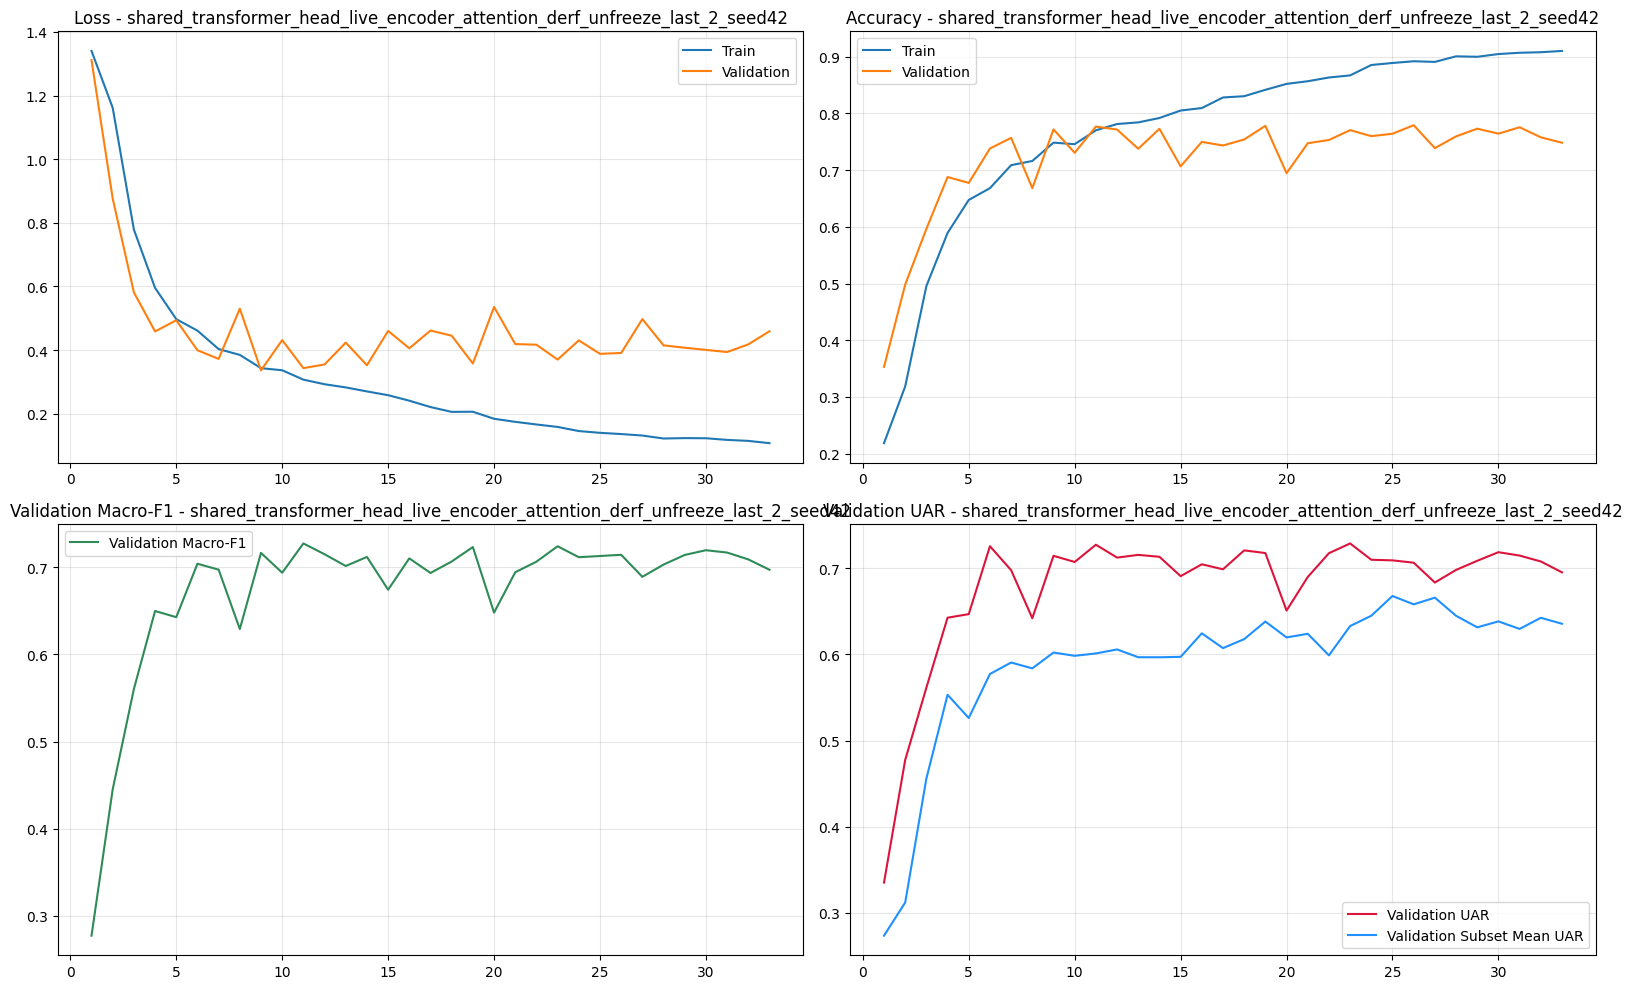

已保存曲线图: checkpoints/shared_transformer_head_live_encoder_attention_derf_unfreeze_last_2_seed42_curves.png


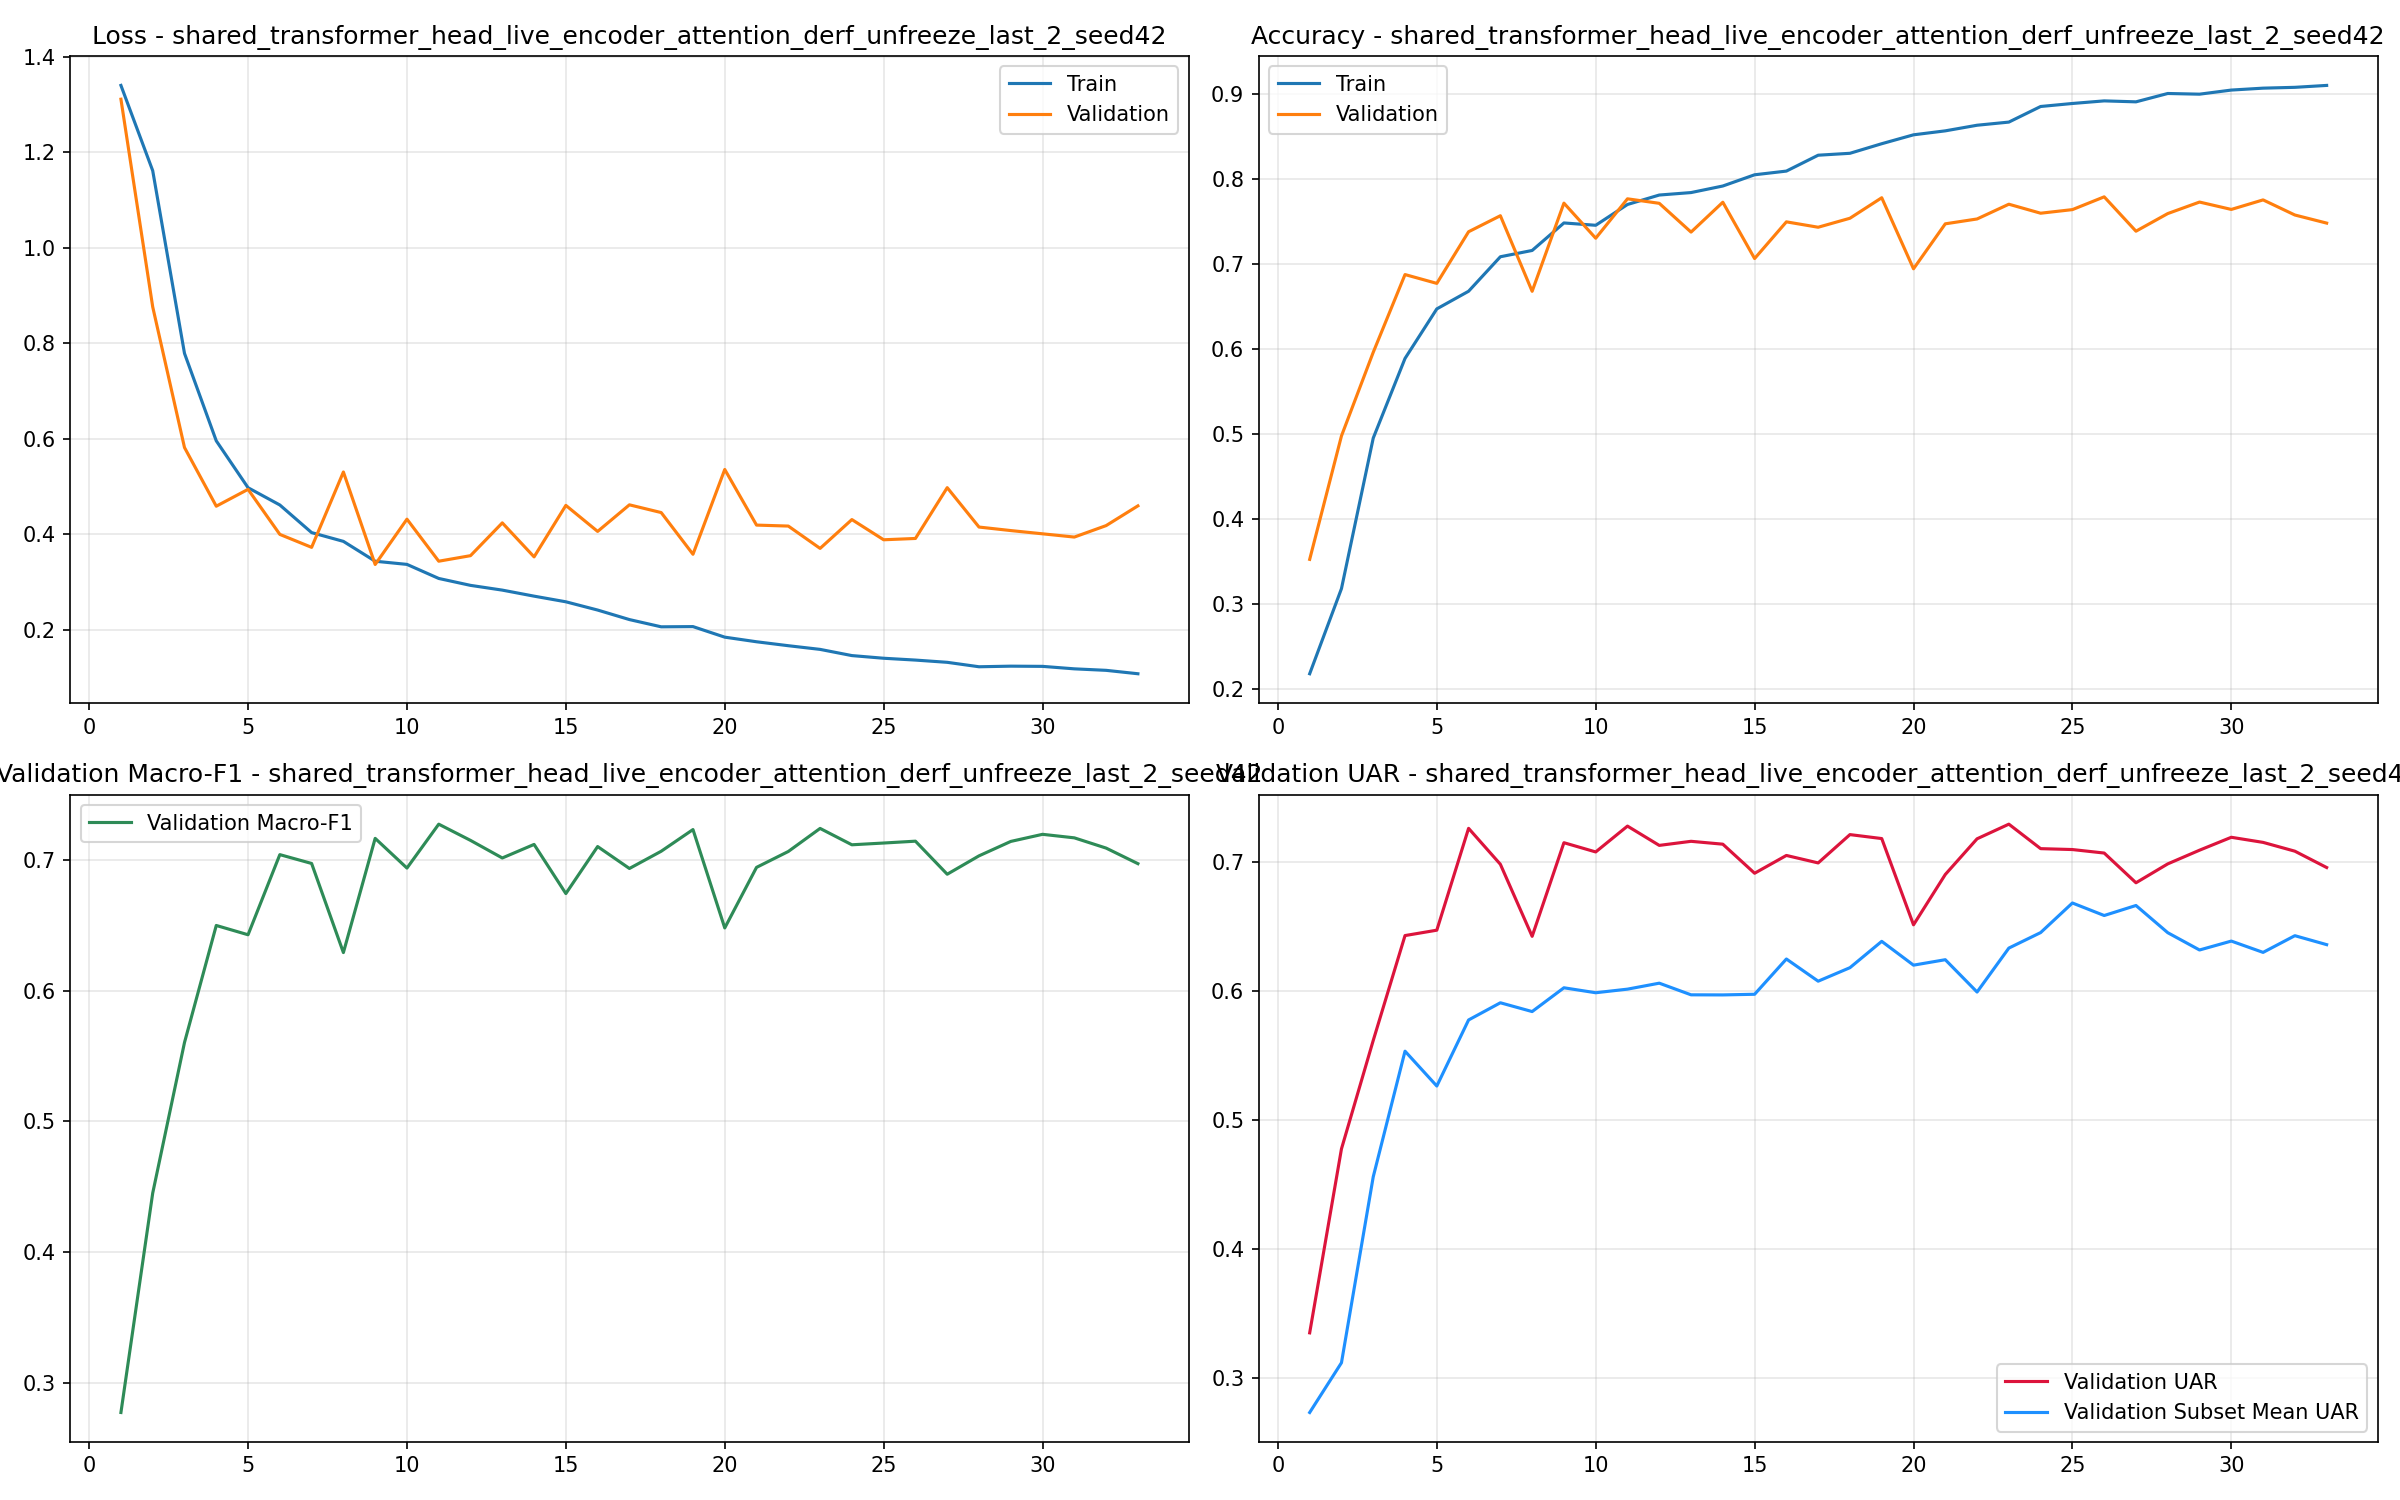

已保存混淆矩阵: checkpoints/shared_transformer_head_live_encoder_attention_derf_unfreeze_last_2_seed42_confusion_matrix.png


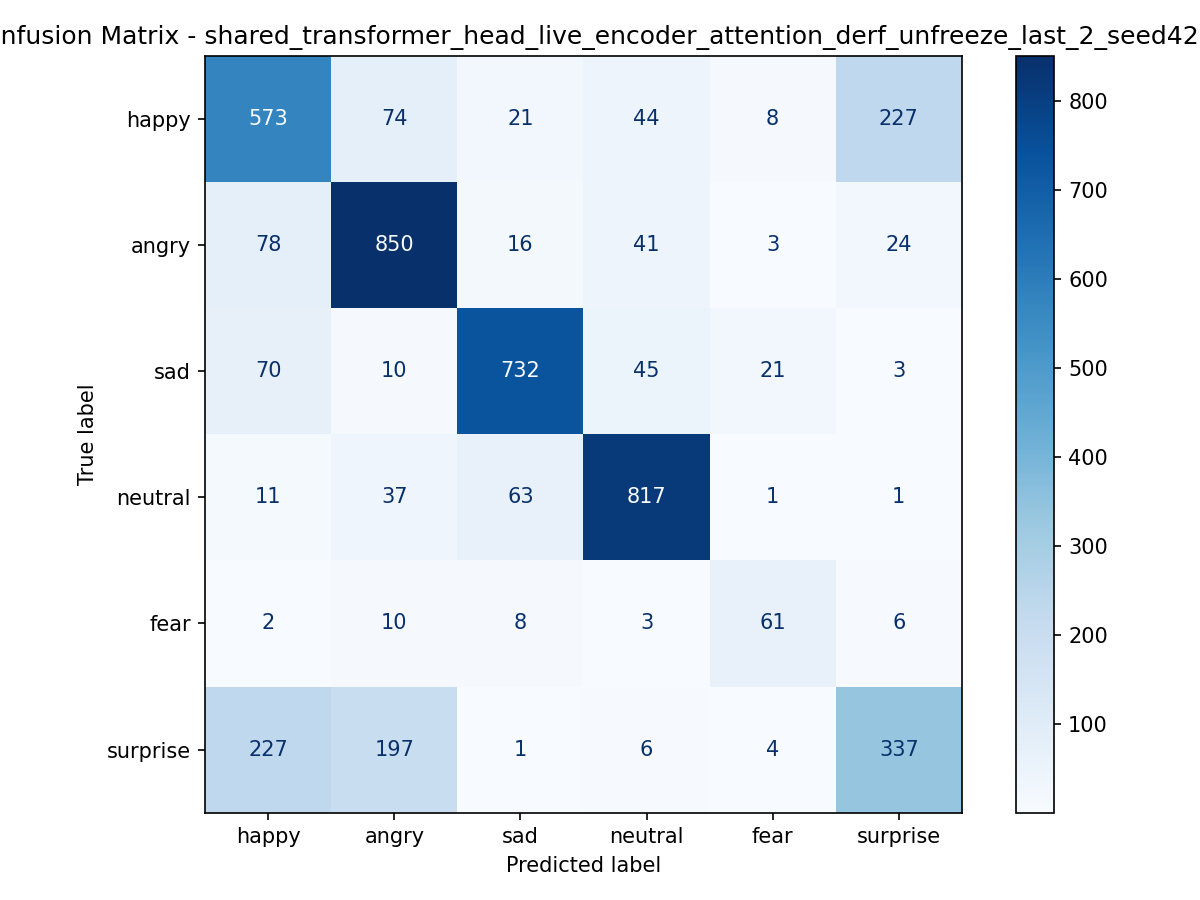

In [4]:
if current_history:
    plot_history_panels(current_history, CURRENT_MAINLINE_RUN)
else:
    print('当前主线缺少 history，无法重绘训练曲线。')

if SHOW_SAVED_IMAGES:
    display_saved_image(current_artifacts['curves'], '已保存曲线图')
    display_saved_image(current_artifacts['confusion_matrix'], '已保存混淆矩阵')


## 4. 跨架构对比：早期探索路线 vs 当前主线

本节读取早期探索路线的 `emotion_history.npz` / `emotion_summary.json`，并与当前主线 run 做横向比较。若某一侧缺少统一 summary，则仍可基于已有 history 绘制曲线，但表格会自动跳过缺失指标。


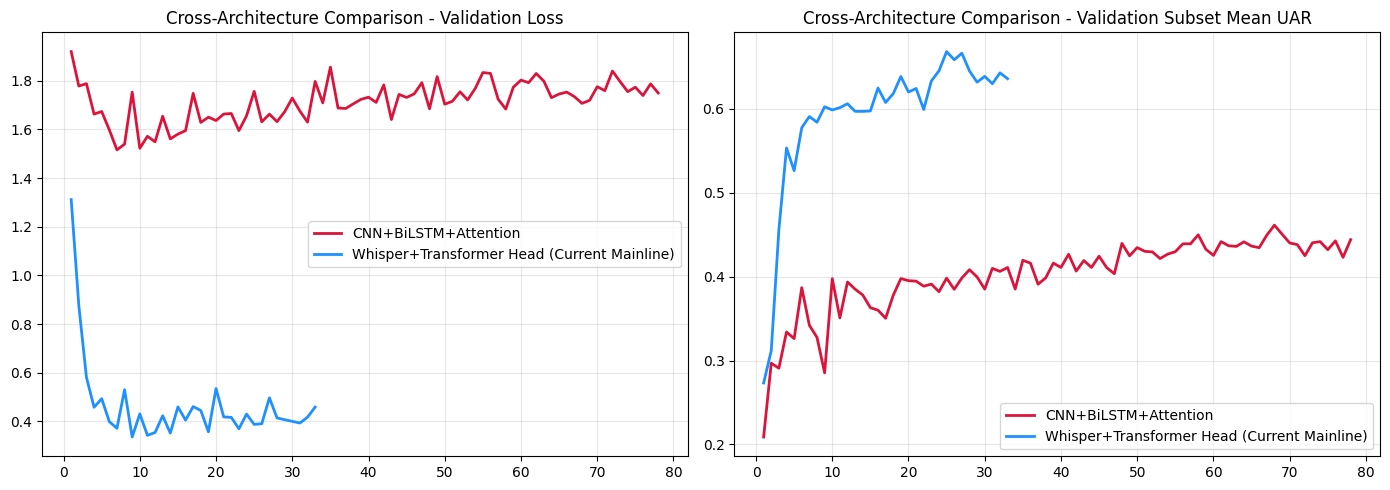

+---------------------------------------------+-----------------+---------------------------+--------------------+-------------------+------------+------------+---------------+------------+
| 模型                                        |   Best Val Loss | Selected Val Subset UAR   | Selected Val UAR   | Test Subset UAR   | Test UAR   |   Macro F1 |   Weighted F1 | Test Acc   |
+=============================================+=================+===========================+====================+===================+============+============+===============+============+
| CNN+BiLSTM+Attention                        |          1.5159 | 46.12%                    | 55.75%             | 42.40%            | 56.90%     |     0.5509 |        0.5775 | 57.85%     |
+---------------------------------------------+-----------------+---------------------------+--------------------+-------------------+------------+------------+---------------+------------+
| Whisper+Transformer Head (Current Mainline) |     

In [5]:
baseline_artifacts = {
    'history': ckpt_dir / 'emotion_history.npz',
    'summary': ckpt_dir / 'emotion_summary.json',
}
baseline = {
    'display_name': 'CNN+BiLSTM+Attention',
    'run_name': 'emotion',
    'history': load_history(baseline_artifacts['history']),
    'summary': load_summary(baseline_artifacts['summary']),
    'artifacts': baseline_artifacts,
}
current = {
    'display_name': 'Whisper+Transformer Head (Current Mainline)',
    'run_name': CURRENT_MAINLINE_RUN,
    'history': current_history,
    'summary': current_summary,
    'artifacts': current_artifacts,
}

architecture_group = {
    baseline['display_name']: baseline,
    current['display_name']: current,
}
plot_history_group(architecture_group, 'Cross-Architecture Comparison')

rows = []
for name, data in architecture_group.items():
    summary = data.get('summary')
    rows.append([
        name,
        format_metric(summary_value(summary or {}, 'best_val_loss')),
        format_metric(summary_value(summary or {}, 'selected_val_subset_mean_uar', 'best_val_subset_mean_uar'), percent=True),
        format_metric(summary_value(summary or {}, 'selected_val_uar', 'best_val_uar'), percent=True),
        format_metric(summary_value(summary or {}, 'test_subset_mean_uar'), percent=True),
        format_metric(summary_value(summary or {}, 'uar'), percent=True),
        format_metric(summary_value(summary or {}, 'macro_f1')),
        format_metric(summary_value(summary or {}, 'weighted_f1')),
        format_metric(summary_value(summary or {}, 'test_acc'), percent=True),
    ])
print_summary_table(
    rows,
    headers=['模型', 'Best Val Loss', 'Selected Val Subset UAR', 'Selected Val UAR', 'Test Subset UAR', 'Test UAR', 'Macro F1', 'Weighted F1', 'Test Acc'],
)


## 5. Derf 与 DyT 关键对比

这里固定主线协议为 `transformer_head + live_encoder + attention + unfreeze_last_2`，只比较 `norm=derf` 与 `norm=dyt`。若当前配置默认主线就是 `Derf`，则它与“Current Mainline”本质上属于同一实验家族，但本节仍会显式保留 `Derf / DyT` 标签，便于论文叙事和关键图表复盘。


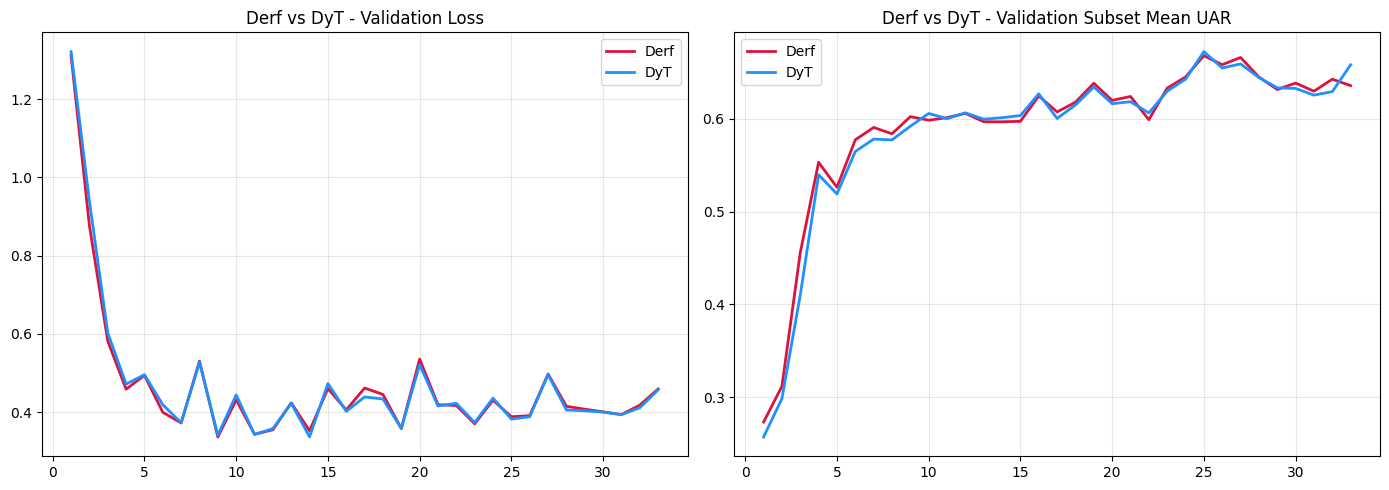

+--------+----------------------------------------------------------------------------+---------------------------+--------------------+-------------------+------------+------------+------------+
| 配置   | run_name                                                                   | Selected Val Subset UAR   | Selected Val UAR   | Test Subset UAR   | Test UAR   |   Macro F1 | Test Acc   |
+========+============================================================================+===========================+====================+===================+============+============+============+
| Derf   | shared_transformer_head_live_encoder_attention_derf_unfreeze_last_2_seed42 | 66.79%                    | 70.93%             | 66.76%            | 71.14%     |     0.7057 | 72.75%     |
+--------+----------------------------------------------------------------------------+---------------------------+--------------------+-------------------+------------+------------+------------+
| DyT    | shared_tran

In [6]:
derf_run = resolve_existing_run_name(DERF_STEM, ANALYSIS_SEED)
dyt_run = resolve_existing_run_name(DYT_STEM, ANALYSIS_SEED)

derf_data = load_experiment('Derf', derf_run)
dyt_data = load_experiment('DyT', dyt_run)
norm_group = {
    'Derf': derf_data,
    'DyT': dyt_data,
}
plot_history_group(norm_group, 'Derf vs DyT')

rows = []
for name, data in norm_group.items():
    summary = data.get('summary')
    rows.append([
        name,
        data['run_name'],
        format_metric(summary_value(summary or {}, 'selected_val_subset_mean_uar', 'best_val_subset_mean_uar'), percent=True),
        format_metric(summary_value(summary or {}, 'selected_val_uar', 'best_val_uar'), percent=True),
        format_metric(summary_value(summary or {}, 'test_subset_mean_uar'), percent=True),
        format_metric(summary_value(summary or {}, 'uar'), percent=True),
        format_metric(summary_value(summary or {}, 'macro_f1')),
        format_metric(summary_value(summary or {}, 'test_acc'), percent=True),
    ])
print_summary_table(
    rows,
    headers=['配置', 'run_name', 'Selected Val Subset UAR', 'Selected Val UAR', 'Test Subset UAR', 'Test UAR', 'Macro F1', 'Test Acc'],
)


## 6. 多 Seed 汇总

本节优先读取已经存在的 `*_aggregate.json`；若尚未生成聚合文件，则仅在 notebook 内基于已有 `seed` 级 summary 进行临时汇总展示，不向 `checkpoints/` 再写回任何新文件。


In [7]:
aggregate_targets = []
current_label = 'Current Mainline'
if CURRENT_MAINLINE_STEM == DERF_STEM:
    current_label = 'Current Mainline (Derf)'
elif CURRENT_MAINLINE_STEM == DYT_STEM:
    current_label = 'Current Mainline (DyT)'
aggregate_targets.append((current_label, CURRENT_MAINLINE_STEM))
if DERF_STEM != CURRENT_MAINLINE_STEM:
    aggregate_targets.append(('Derf', DERF_STEM))
if DYT_STEM != CURRENT_MAINLINE_STEM:
    aggregate_targets.append(('DyT', DYT_STEM))

rows = []
for label, stem in aggregate_targets:
    aggregate = load_aggregate_or_compute(stem, seed_sweep)
    if not aggregate:
        rows.append([label, stem, 'n/a', 'n/a', 'n/a', 'n/a', 'n/a', 'n/a'])
        continue
    summary = aggregate['summary']
    metric = summary.get('aggregate_mean_std', {})

    def fmt_mean_std(key, percent=False):
        if key not in metric:
            return 'n/a'
        mean = metric[key]['mean']
        std = metric[key]['std']
        if percent:
            return f'{mean:.2%} ± {std:.2%}'
        return f'{mean:.4f} ± {std:.4f}'

    rows.append([
        label,
        aggregate['source'],
        fmt_mean_std('selected_val_subset_mean_uar', percent=True),
        fmt_mean_std('selected_val_uar', percent=True),
        fmt_mean_std('test_subset_mean_uar', percent=True),
        fmt_mean_std('uar', percent=True),
        fmt_mean_std('macro_f1'),
        fmt_mean_std('test_acc', percent=True),
    ])

print_summary_table(
    rows,
    headers=['实验家族', '来源', 'Selected Val Subset UAR', 'Selected Val UAR', 'Test Subset UAR', 'Test UAR', 'Macro F1', 'Test Acc'],
)


+-------------------------+------------------------------------------------------------------------------------------------+---------------------------+--------------------+-------------------+----------------+-----------------+----------------+
| 实验家族                | 来源                                                                                           | Selected Val Subset UAR   | Selected Val UAR   | Test Subset UAR   | Test UAR       | Macro F1        | Test Acc       |
+=========================+================================================================================================+===========================+====================+===================+================+=================+================+
| Current Mainline (Derf) | checkpoints/shared_transformer_head_live_encoder_attention_derf_unfreeze_last_2_aggregate.json | 66.79% ± 0.00%            | 70.93% ± 0.00%     | 66.76% ± 0.00%    | 71.14% ± 0.00% | 0.7057 ± 0.0000 | 72.75% ± 0.00% |
+---------------------

## 7. 可选附录：冻结策略兼容参考

当前论文主叙事不再把冻结策略作为默认对比变量，因此本节默认关闭，仅在你手头已经有对应 artifacts 时再手动打开查看。这里同样只做读取与可视化，不会触发任何新训练。


In [8]:
FREEZE_REFERENCE = {
    'Derf + freeze_all': build_transformer_experiment_stem('derf', 'freeze_all'),
    'Derf + unfreeze_last_2': build_transformer_experiment_stem('derf', 'unfreeze_last_2'),
    'Derf + unfreeze_last_4': build_transformer_experiment_stem('derf', 'unfreeze_last_4'),
}

if RUN_OPTIONAL_FREEZE_REFERENCE:
    freeze_group = {
        label: load_experiment(label, resolve_existing_run_name(stem, ANALYSIS_SEED))
        for label, stem in FREEZE_REFERENCE.items()
    }
    plot_history_group(freeze_group, 'Freeze Strategy Reference')

    rows = []
    for name, data in freeze_group.items():
        summary = data.get('summary')
        rows.append([
            name,
            data['run_name'],
            format_metric(summary_value(summary or {}, 'selected_val_subset_mean_uar', 'best_val_subset_mean_uar'), percent=True),
            format_metric(summary_value(summary or {}, 'selected_val_uar', 'best_val_uar'), percent=True),
            format_metric(summary_value(summary or {}, 'test_subset_mean_uar'), percent=True),
            format_metric(summary_value(summary or {}, 'uar'), percent=True),
        ])
    print_summary_table(
        rows,
        headers=['配置', 'run_name', 'Selected Val Subset UAR', 'Selected Val UAR', 'Test Subset UAR', 'Test UAR'],
    )
else:
    print('已跳过冻结策略参考；当前 notebook 默认只保留主线分析、跨架构对比、Derf/DyT 对比与多 seed 汇总。')


已跳过冻结策略参考；当前 notebook 默认只保留主线分析、跨架构对比、Derf/DyT 对比与多 seed 汇总。
